<a href="https://colab.research.google.com/github/lamphyon/EmailSpamdetector_withnaivebayes/blob/main/spamdetector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implementasi Algoritma Naive-Bayes

Kelompok 6 \
Kelas Probabilistik dan Statistik (F)

Anggota kelompok:
1. Fauzan Hafiz Amandani (5025241087)
2. Willy Dava Nugraha (5025241090)
3. Farras Abdurrazaq Ar rasyid (5025241091)
4. Abdullah Sultan Barizy (5025241092)


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import os
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt

## dataset yang digunakan

In [ ]:
path = kagglehub.dataset_download("shantanudhakadd/email-spam-detection-dataset-classification")

Using Colab cache for faster access to the 'email-spam-detection-dataset-classification' dataset.


In [ ]:
path

'/kaggle/input/email-spam-detection-dataset-classification'

## karena masih berupa folder cari dahulu file datasetnya

In [ ]:
print(os.path.isdir(path))

True


In [ ]:
contents = os.listdir(path)
print(contents)

['spam.csv']


In [ ]:
path_csv = path + '/spam.csv'

path_csv

'/kaggle/input/email-spam-detection-dataset-classification/spam.csv'

## buka file dataset

In [ ]:
df = pd.read_csv(
    path_csv,
    encoding_errors="ignore"
)

df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will _ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


## hanya menggunakan kolom yang berisi email dan labelnya (spam/ham)

In [ ]:
df = df[['v1','v2']]

df

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will _ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


## ubah label string menjadi angka

In [ ]:
df["v1"] = df["v1"].map({"ham": 0, "spam": 1})

df

/tmp/ipykernel_434/3274868655.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["v1"] = df["v1"].map({"ham": 0, "spam": 1})


,v1,v2
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will _ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


## bagi data menjadi data latih dan data uji

In [ ]:
# Membagi Data (75% Training, 25% Testing)
X_train, X_test, y_train, y_test = train_test_split(
    df['v2'],
    df['v1'],
    test_size=0.25,
    random_state=42,
    stratify=df['v1']
)

## ekstraksi fitur

In [ ]:
# Ekstraksi Fitur (Ubah Teks jadi Angka Frekuensi)
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

## latih model

In [ ]:
# Melatih Model Naive Bayes
model = MultinomialNB()
model.fit(X_train_vec, y_train)

MultinomialNB()

## evaluasi hasil


================ E V A L U A S I ================
Akurasi Model: 98.56%

--- Laporan Klasifikasi ---
              precision    recall  f1-score   support

     Ham (0)       0.99      1.00      0.99      1206
    Spam (1)       0.98      0.91      0.94       187

    accuracy                           0.99      1393
   macro avg       0.98      0.96      0.97      1393
weighted avg       0.99      0.99      0.99      1393



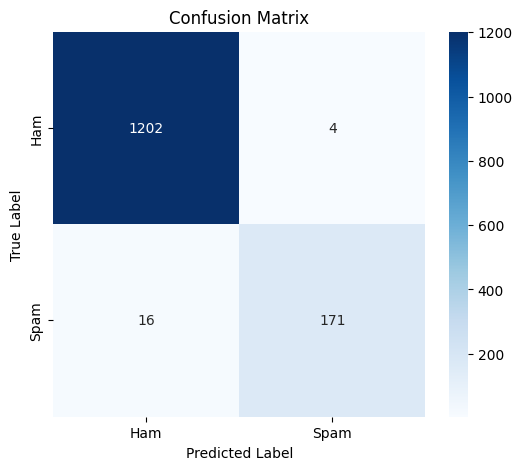

In [ ]:
# 6. EVALUASI HASIL
print("================ E V A L U A S I ================")
print(f"Akurasi Model: {accuracy_score(y_test, prediksi) * 100:.2f}%\n")

print("--- Laporan Klasifikasi ---")
print(classification_report(y_test, prediksi, target_names=['Ham (0)', 'Spam (1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, prediksi)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,           # show numbers
    fmt="d",              # integer format
    cmap="Blues",
    xticklabels=['Ham','Spam'],
    yticklabels=['Ham','Spam']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## detail tebakan data uji

In [ ]:
print("\n================ DETAIL TEBAKAN DATA UJI ================")
for teks, label_asli, label_prediksi in zip(X_test, y_test, prediksi):
    status_asli = "SPAM" if label_asli == 1 else "AMAN"
    status_prediksi = "SPAM" if label_prediksi == 1 else "AMAN"
    kesesuaian = "BENAR" if label_asli == label_prediksi else "SALAH"

    print(f"Teks    : {teks}")
    print(f"Asli    : {status_asli}")
    print(f"Tebakan : {status_prediksi} ({kesesuaian})")
    print("-" * 60)


================ DETAIL TEBAKAN DATA UJI ================
Teks    : We left already we at orchard now.
Asli    : AMAN
Tebakan : AMAN (BENAR)
------------------------------------------------------------
Teks    : Hi babe its Jordan, how r u? Im home from abroad and lonely, text me back if u wanna chat xxSP visionsms.com Text stop to stopCost 150p 08712400603
Asli    : SPAM
Tebakan : AMAN (SALAH)
------------------------------------------------------------
Teks    : Nothing. I meant that once the money enters your account here, the bank will remove its flat rate. Someone transfered  &lt;#&gt;  to my account and  &lt;#&gt; dollars got removed. So the banks differ and charges also differ.be sure you trust the 9ja person you are sending account details to cos...
Asli    : AMAN
Tebakan : AMAN (BENAR)
------------------------------------------------------------
Teks    : The word \Checkmate\" in chess comes from the Persian phrase \"Shah Maat\" which means; \"the king is dead..\" Goodmorning